In [1]:
import sys
sys.path.append('..')

import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numcodecs import Blosc
from scipy.stats import wasserstein_distance

In [2]:
LogT = [5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2]

In [3]:
# Cargar archivos
npz_files = {
    'lp': np.load(os.path.join(r"..\data\train", "20240520_1200.npz")),
    'qp': np.load(os.path.join(r"..\data\train", "20240520_1200_qp.npz")),
    'enet': np.load(os.path.join(r"..\data\train", "20240520_1200_enet.npz")),
    'lbfgs_lp': np.load(os.path.join(r"..\data\train", "20240520_1200_lbgfs.npz")),
    'lbfgs_qp': np.load(os.path.join(r"..\data\train", "20240520_1200_lbgfs_qp.npz")),
    'lbfgs_enet': np.load(os.path.join(r"..\data\train", "20240520_1200_lbgfs_enetv2.npz"))
}

compressor = Blosc(cname='zstd', clevel=4, shuffle=2)

# Decodificar todos los DEMs
dems = {
    method: np.frombuffer(
        compressor.decode(npz["DEMCube"]),
        dtype=np.float32
    ).reshape(npz["DEMCubeShape"])
    for method, npz in npz_files.items()
}


In [4]:
dem_lp = dems['lp']
dem_qp = dems['qp']
dem_enet = dems['enet']
dem_lbfgs_lp = dems['lbfgs_lp']
dem_lbfgs_qp = dems['lbfgs_qp']
dem_lbfgs_enet = dems['lbfgs_enet']

In [5]:
for method, dem in dems.items():
    print(method, dem.shape)

lp (18, 16, 16)
qp (18, 16, 16)
enet (18, 16, 16)
lbfgs_lp (18, 16, 16)
lbfgs_qp (18, 16, 16)
lbfgs_enet (18, 16, 16)


In [6]:
plt.rcParams["figure.dpi"] = 200
plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'serif'

In [8]:
def style_ax(a):
    a.set_xticks([])
    a.set_yticks([])
    for spine in a.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

In [7]:
total_em_lp = np.sum(dem_lp, axis=0)
total_em_lbfgs_lp = np.sum(dem_lbfgs_lp, axis=0)

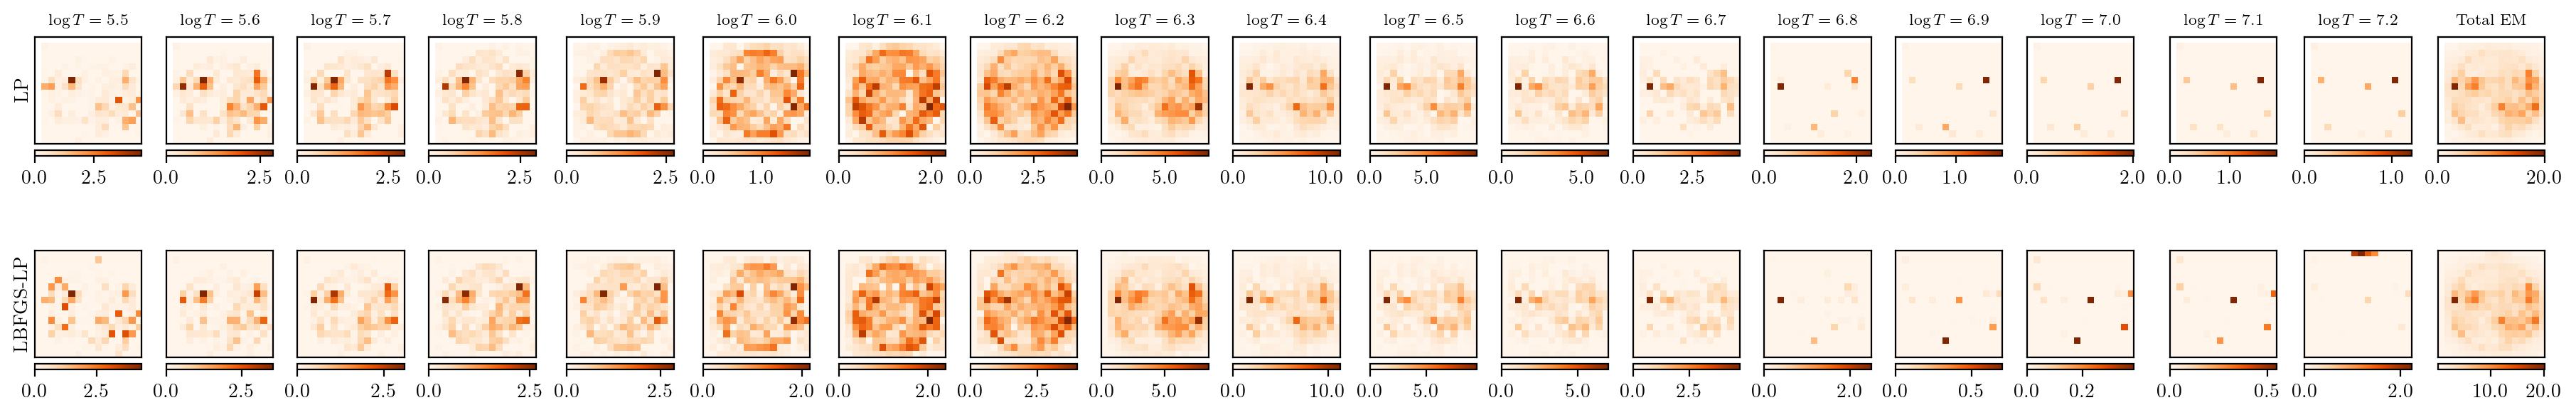

In [ ]:
fig, ax = plt.subplots(2, 19, figsize=(18, 3), constrained_layout=True)

cmap = 'Oranges'

for ch in range(18):
    im = ax[0, ch].imshow(dem_lp[ch]**0.5, cmap=cmap)
    ax[0, ch].set_title(fr"$\log T = {LogT[ch]:.1f}$", fontsize=8)
    style_ax(ax[0, ch])
    fig.colorbar(im, ax=ax[0, ch], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)
    
    im = ax[1, ch].imshow(dem_lbfgs_lp[ch]**0.5, cmap=cmap)
    style_ax(ax[1, ch])
    fig.colorbar(im, ax=ax[1, ch], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

im2 = ax[0, 18].imshow(total_em_lp**0.5, cmap=cmap)
ax[0, 18].set_title("Total EM", fontsize=8)
style_ax(ax[0, 18])
fig.colorbar(im2, ax=ax[0, 18], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)
im2 = ax[1, 18].imshow(total_em_lbfgs_lp**0.5, cmap=cmap)
style_ax(ax[1, 18])
fig.colorbar(im2, ax=ax[1, 18], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

for row, label in enumerate(["LP", "LBFGS-LP"]):
    ax[row, 0].set_ylabel(label, fontsize=10, fontweight='bold',
                          rotation=90, labelpad=6, va='center')
plt.show()

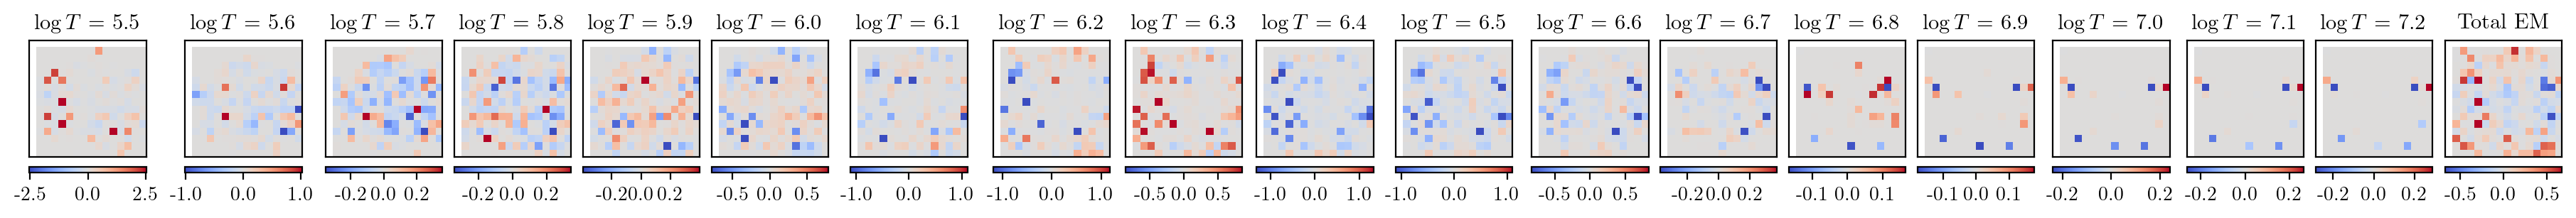

In [29]:
fig, ax = plt.subplots(1, 19, figsize=(18, 2), constrained_layout=True)

cmap = 'coolwarm'
for ch in range(0, 18):
    diff = dem_lbfgs_lp[ch]**0.5 - dem_lp[ch]**0.5
    vmax_diff = np.nanpercentile(np.abs(diff), 99)
    im = ax[ch].imshow(diff, cmap=cmap, vmin=-vmax_diff, vmax=vmax_diff)
    ax[ch].set_title(fr"$\log T$ = {LogT[ch]:.1f}", fontsize=11, fontweight='bold')
    style_ax(ax[ch])
    fig.colorbar(im, ax=ax[ch], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

ax[0].axis('on')
ax[0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

diff_total = total_em_lbfgs_lp**0.5 - total_em_lp**0.5
vmax_total = np.nanpercentile(np.abs(diff_total), 99)
im_total = ax[18].imshow(diff_total, cmap=cmap, vmin=-vmax_total, vmax=vmax_total)
ax[18].set_title("Total EM", fontsize=11, fontweight='bold')
style_ax(ax[18])
fig.colorbar(im_total, ax=ax[18], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

plt.show()

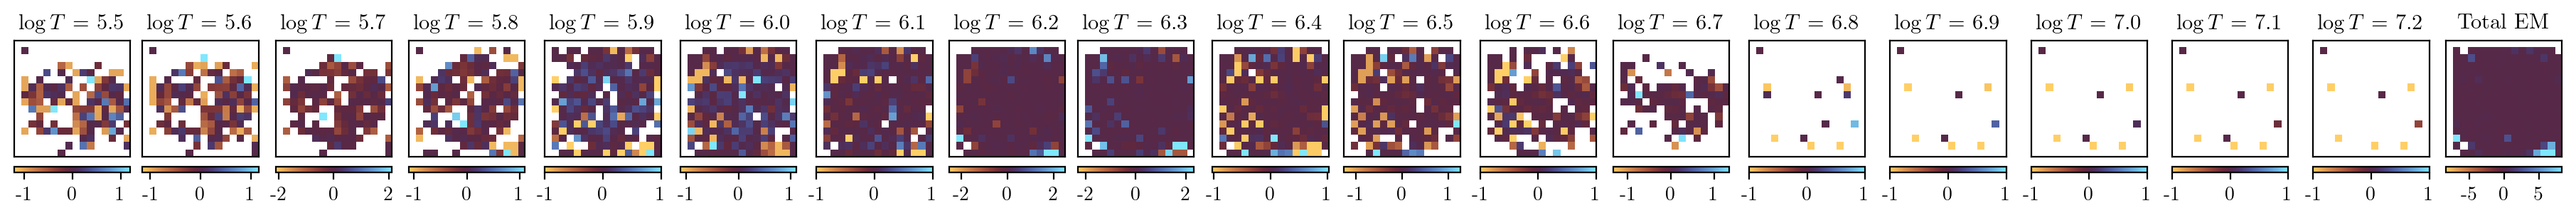

In [37]:
fig, ax = plt.subplots(1, 19, figsize=(18, 2), constrained_layout=True)

cmap = 'managua'
for ch in range(0, 18):
    diff = ( dem_lbfgs_lp[ch]**0.5 - dem_lp[ch]**0.5) / np.where(dem_lp[ch] > 0, dem_lp[ch]**0.5, np.nan)
    vmax_diff = np.nanpercentile(np.abs(diff), 99)
    im = ax[ch].imshow(diff, cmap=cmap, vmin=-vmax_diff, vmax=vmax_diff)
    ax[ch].set_title(fr"$\log T$ = {LogT[ch]:.1f}", fontsize=11, fontweight='bold')
    style_ax(ax[ch])
    fig.colorbar(im, ax=ax[ch], format='%.0f%%', orientation='horizontal', fraction=0.046, pad=0.04)

ax[0].axis('on')
ax[0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

diff_total = (total_em_lbfgs_lp**0.5 - total_em_lp**0.5) / np.where(total_em_lp > 0, total_em_lp*0.5, np.nan)
vmax_total = np.nanpercentile(np.abs(diff_total), 99)
im_total = ax[18].imshow(diff_total, cmap=cmap, vmin=-vmax_total, vmax=vmax_total)
ax[18].set_title("Total EM", fontsize=11, fontweight='bold')
style_ax(ax[18])
fig.colorbar(im_total, ax=ax[18], format='%.0f%%', orientation='horizontal', fraction=0.046, pad=0.04)

plt.show()

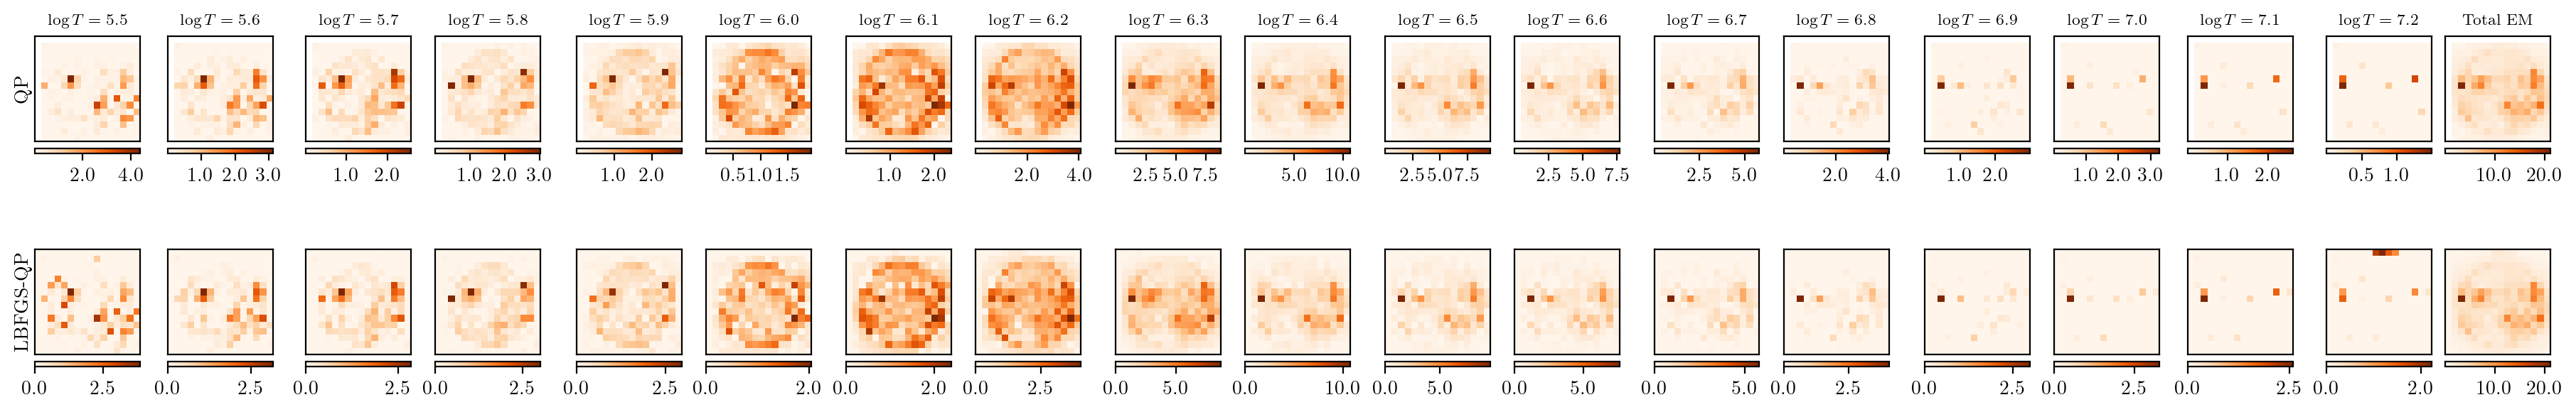

In [38]:
total_em_qp = np.sum(dem_qp, axis=0)
total_em_lbfgs_qp = np.sum(dem_lbfgs_qp, axis=0)

fig, ax = plt.subplots(2, 19, figsize=(18, 3), constrained_layout=True)

cmap = 'Oranges'

for ch in range(18):
    im = ax[0, ch].imshow(dem_qp[ch]**0.5, cmap=cmap)
    ax[0, ch].set_title(fr"$\log T = {LogT[ch]:.1f}$", fontsize=8)
    style_ax(ax[0, ch])
    fig.colorbar(im, ax=ax[0, ch], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)
    
    im = ax[1, ch].imshow(dem_lbfgs_qp[ch]**0.5, cmap=cmap)
    style_ax(ax[1, ch])
    fig.colorbar(im, ax=ax[1, ch], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

im2 = ax[0, 18].imshow(total_em_qp**0.5, cmap=cmap)
ax[0, 18].set_title("Total EM", fontsize=8)
style_ax(ax[0, 18])
fig.colorbar(im2, ax=ax[0, 18], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)
im2 = ax[1, 18].imshow(total_em_lbfgs_qp**0.5, cmap=cmap)
style_ax(ax[1, 18])
fig.colorbar(im2, ax=ax[1, 18], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

for row, label in enumerate(["QP", "LBFGS-QP"]):
    ax[row, 0].set_ylabel(label, fontsize=10, fontweight='bold',
                          rotation=90, labelpad=6, va='center')
plt.show()

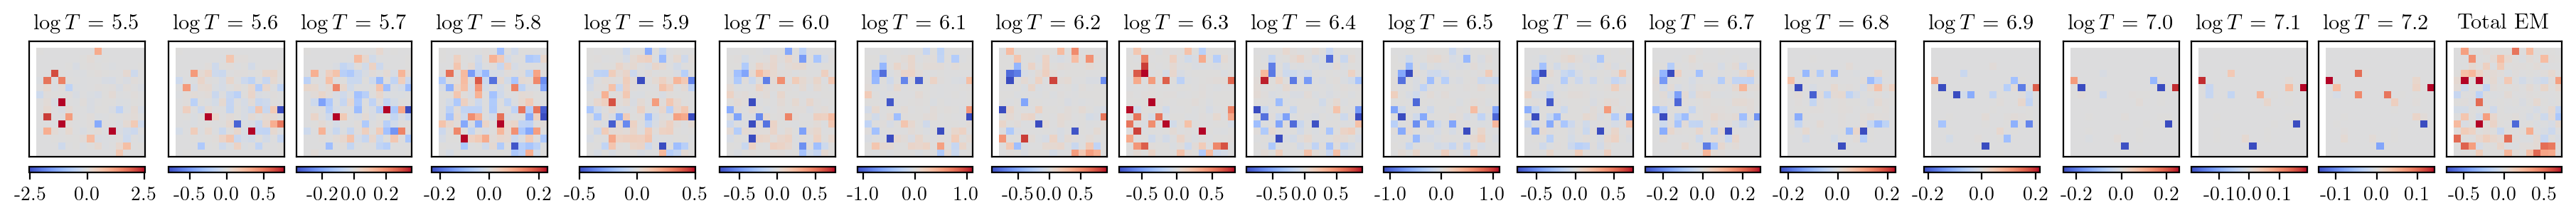

In [39]:
fig, ax = plt.subplots(1, 19, figsize=(18, 2), constrained_layout=True)

cmap = 'coolwarm'
for ch in range(0, 18):
    diff = dem_lbfgs_qp[ch]**0.5 - dem_qp[ch]**0.5
    vmax_diff = np.nanpercentile(np.abs(diff), 99)
    im = ax[ch].imshow(diff, cmap=cmap, vmin=-vmax_diff, vmax=vmax_diff)
    ax[ch].set_title(fr"$\log T$ = {LogT[ch]:.1f}", fontsize=11, fontweight='bold')
    style_ax(ax[ch])
    fig.colorbar(im, ax=ax[ch], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

ax[0].axis('on')
ax[0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

diff_total = total_em_lbfgs_qp**0.5 - total_em_qp**0.5
vmax_total = np.nanpercentile(np.abs(diff_total), 99)
im_total = ax[18].imshow(diff_total, cmap=cmap, vmin=-vmax_total, vmax=vmax_total)
ax[18].set_title("Total EM", fontsize=11, fontweight='bold')
style_ax(ax[18])
fig.colorbar(im_total, ax=ax[18], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

plt.show()

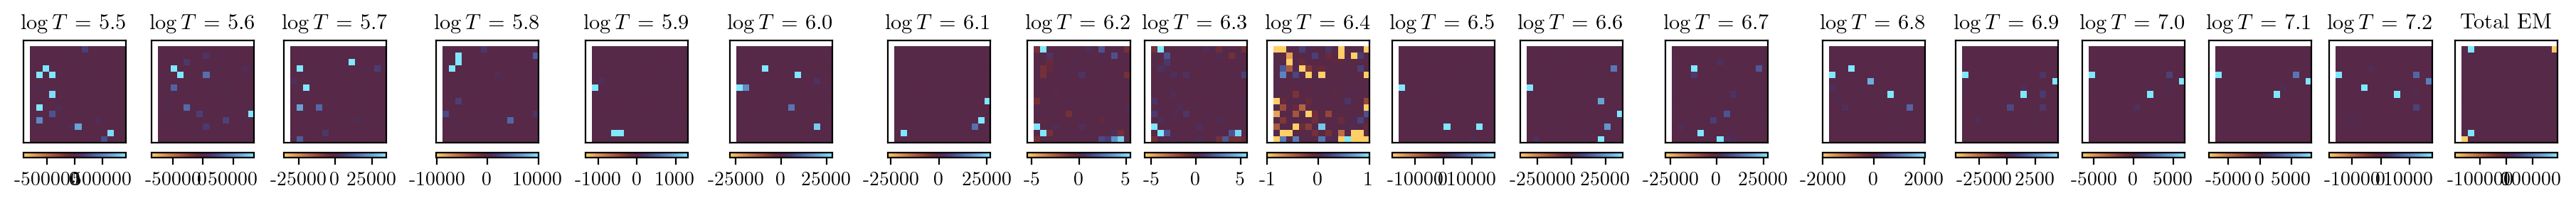

In [43]:
fig, ax = plt.subplots(1, 19, figsize=(18, 2), constrained_layout=True)

cmap = 'managua'
for ch in range(0, 18):
    diff = ( dem_lbfgs_qp[ch]**0.5 - dem_qp[ch]**0.5) / np.where(dem_qp[ch] > 0, dem_qp[ch]**0.5, np.nan)
    vmax_diff = np.nanpercentile(np.abs(diff), 99)
    im = ax[ch].imshow(diff, cmap=cmap, vmin=-vmax_diff, vmax=vmax_diff)
    ax[ch].set_title(fr"$\log T$ = {LogT[ch]:.1f}", fontsize=11, fontweight='bold')
    style_ax(ax[ch])
    fig.colorbar(im, ax=ax[ch], format='%.0f%%', orientation='horizontal', fraction=0.046, pad=0.04)

ax[0].axis('on')
ax[0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

diff_total = (total_em_lbfgs_qp**0.5 - total_em_qp**0.5) / np.where(total_em_qp > 0, total_em_qp*0.5, np.nan)
vmax_total = np.nanpercentile(np.abs(diff_total), 99)
im_total = ax[18].imshow(diff_total, cmap=cmap, vmin=-vmax_total, vmax=vmax_total)
ax[18].set_title("Total EM", fontsize=11, fontweight='bold')
style_ax(ax[18])
fig.colorbar(im_total, ax=ax[18], format='%.0f%%', orientation='horizontal', fraction=0.046, pad=0.04)

plt.show()

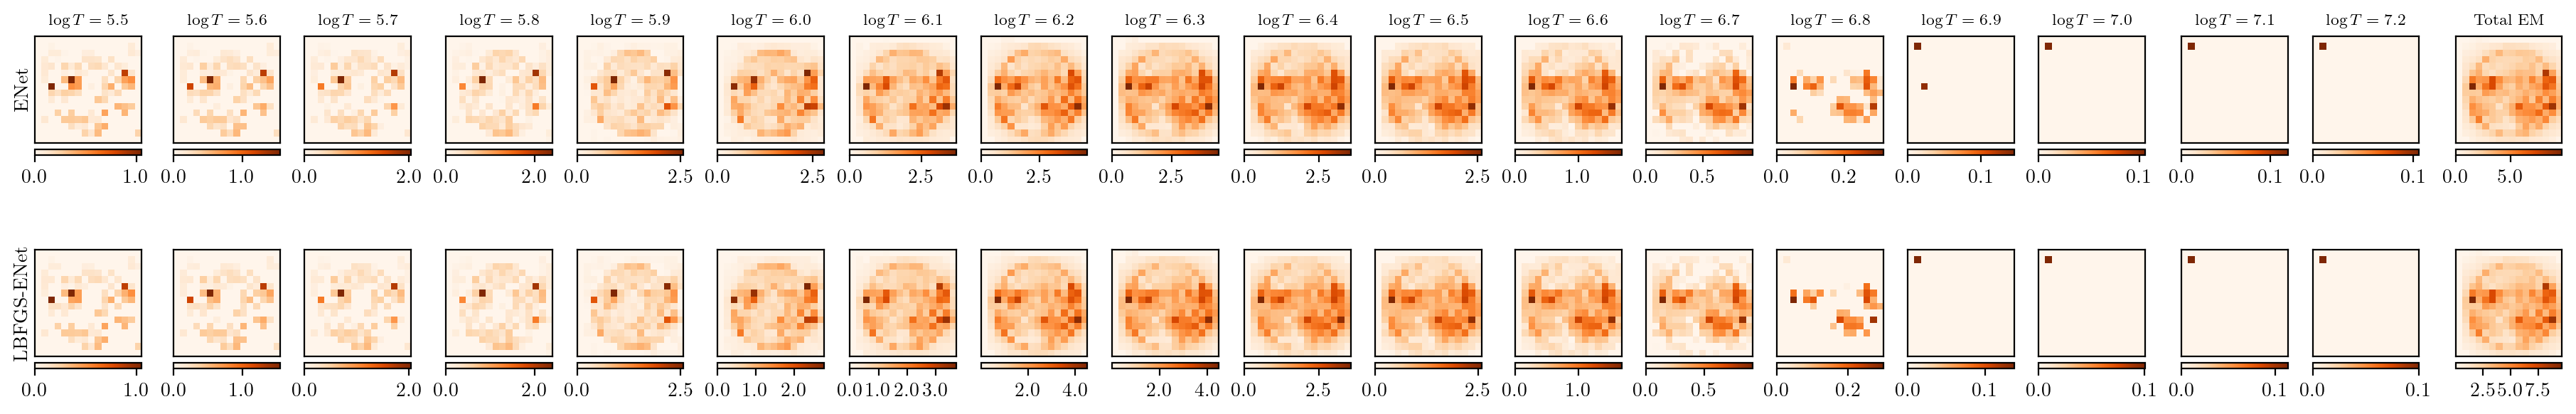

In [9]:
total_em_enet = np.sum(dem_enet, axis=0)
total_em_lbfgs_enet = np.sum(dem_lbfgs_enet, axis=0)

fig, ax = plt.subplots(2, 19, figsize=(18, 3), constrained_layout=True)

cmap = 'Oranges'

for ch in range(18):
    im = ax[0, ch].imshow(dem_enet[ch]**0.5, cmap=cmap)
    ax[0, ch].set_title(fr"$\log T = {LogT[ch]:.1f}$", fontsize=8)
    style_ax(ax[0, ch])
    fig.colorbar(im, ax=ax[0, ch], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)
    
    im = ax[1, ch].imshow(dem_lbfgs_enet[ch]**0.5, cmap=cmap)
    style_ax(ax[1, ch])
    fig.colorbar(im, ax=ax[1, ch], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

im2 = ax[0, 18].imshow(total_em_enet**0.5, cmap=cmap)
ax[0, 18].set_title("Total EM", fontsize=8)
style_ax(ax[0, 18])
fig.colorbar(im2, ax=ax[0, 18], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)
im2 = ax[1, 18].imshow(total_em_lbfgs_enet**0.5, cmap=cmap)
style_ax(ax[1, 18])
fig.colorbar(im2, ax=ax[1, 18], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

for row, label in enumerate(["ENet", "LBFGS-ENet"]):
    ax[row, 0].set_ylabel(label, fontsize=10, fontweight='bold',
                          rotation=90, labelpad=6, va='center')
plt.show()

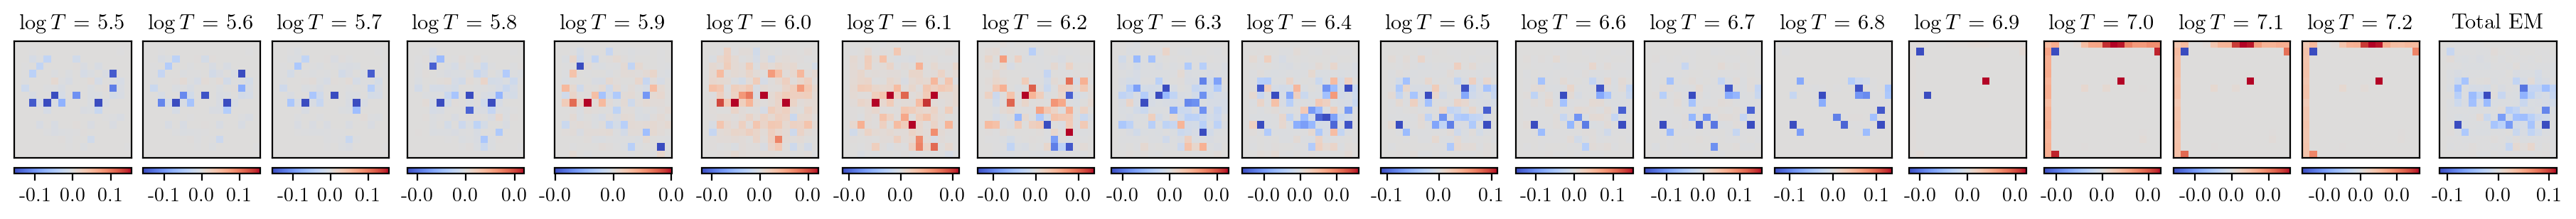

In [10]:
fig, ax = plt.subplots(1, 19, figsize=(18, 2), constrained_layout=True)

cmap = 'coolwarm'
for ch in range(0, 18):
    diff = dem_lbfgs_enet[ch]**0.5 - dem_enet[ch]**0.5
    vmax_diff = np.nanpercentile(np.abs(diff), 99)
    im = ax[ch].imshow(diff, cmap=cmap, vmin=-vmax_diff, vmax=vmax_diff)
    ax[ch].set_title(fr"$\log T$ = {LogT[ch]:.1f}", fontsize=11, fontweight='bold')
    style_ax(ax[ch])
    fig.colorbar(im, ax=ax[ch], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

ax[0].axis('on')
ax[0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

diff_total = total_em_lbfgs_enet**0.5 - total_em_enet**0.5
vmax_total = np.nanpercentile(np.abs(diff_total), 99)
im_total = ax[18].imshow(diff_total, cmap=cmap, vmin=-vmax_total, vmax=vmax_total)
ax[18].set_title("Total EM", fontsize=11, fontweight='bold')
style_ax(ax[18])
fig.colorbar(im_total, ax=ax[18], format='%.1f', orientation='horizontal', fraction=0.046, pad=0.04)

plt.show()

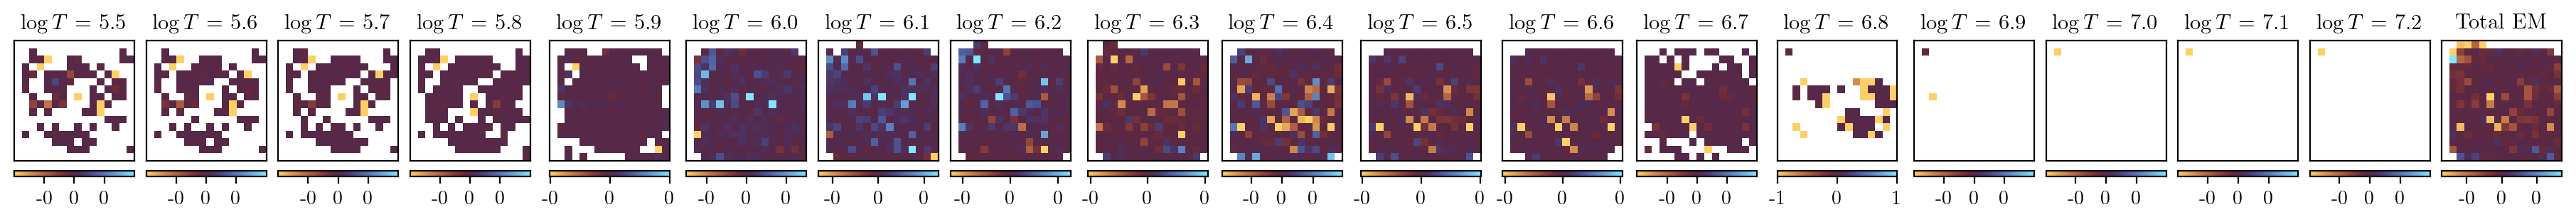

In [11]:
fig, ax = plt.subplots(1, 19, figsize=(18, 2), constrained_layout=True)

cmap = 'managua'
for ch in range(0, 18):
    diff = ( dem_lbfgs_enet[ch]**0.5 - dem_enet[ch]**0.5) / np.where(dem_enet[ch] > 0, dem_enet[ch]**0.5, np.nan)
    vmax_diff = np.nanpercentile(np.abs(diff), 99)
    im = ax[ch].imshow(diff, cmap=cmap, vmin=-vmax_diff, vmax=vmax_diff)
    ax[ch].set_title(fr"$\log T$ = {LogT[ch]:.1f}", fontsize=11, fontweight='bold')
    style_ax(ax[ch])
    fig.colorbar(im, ax=ax[ch], format='%.0f%%', orientation='horizontal', fraction=0.046, pad=0.04)

ax[0].axis('on')
ax[0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

diff_total = (total_em_lbfgs_enet**0.5 - total_em_enet**0.5) / np.where(total_em_enet > 0, total_em_enet*0.5, np.nan)
vmax_total = np.nanpercentile(np.abs(diff_total), 99)
im_total = ax[18].imshow(diff_total, cmap=cmap, vmin=-vmax_total, vmax=vmax_total)
ax[18].set_title("Total EM", fontsize=11, fontweight='bold')
style_ax(ax[18])
fig.colorbar(im_total, ax=ax[18], format='%.0f%%', orientation='horizontal', fraction=0.046, pad=0.04)

plt.show()

In [12]:
from scipy.stats import wasserstein_distance

def wasserstein_map(dem1: np.ndarray, dem2: np.ndarray, logT: np.ndarray) -> np.ndarray:
    logT = np.asarray(logT)
    _, H, W = dem1.shape
    dist_map = np.zeros((H, W))

    for i in range(H):
        for j in range(W):
            w1 = dem1[:, i, j]
            w2 = dem2[:, i, j]

            # saltar píxeles con pesos inválidos
            if not (np.isfinite(w1).all() and np.isfinite(w2).all()):
                dist_map[i, j] = np.nan
                continue
            if w1.sum() <= 0 or w2.sum() <= 0:
                dist_map[i, j] = np.nan
                continue

            dist_map[i, j] = wasserstein_distance(
                u_values=logT,
                v_values=logT,
                u_weights=w1,
                v_weights=w2,
            )

    return dist_map

In [13]:
from scipy.spatial.distance import jensenshannon

def js_map(dem1: np.ndarray, dem2: np.ndarray) -> np.ndarray:
    _, H, W = dem1.shape
    dist_map = np.zeros((H, W))

    for i in range(H):
        for j in range(W):
            w1 = dem1[:, i, j]
            w2 = dem2[:, i, j]

            if not (np.isfinite(w1).all() and np.isfinite(w2).all()):
                dist_map[i, j] = np.nan
                continue

            dist_map[i, j] = jensenshannon(w1, w2)

    return dist_map

In [14]:
w1_map_lp = wasserstein_map(dem_lbfgs_lp, dem_lp, np.asarray(LogT))
w1_map_qp = wasserstein_map(dem_lbfgs_qp, dem_qp, np.asarray(LogT))
w1_map_enet = wasserstein_map(dem_lbfgs_enet, dem_enet, np.asarray(LogT))


In [15]:
js_map_lp = js_map(dem_lbfgs_lp, dem_lp)
js_map_qp = js_map(dem_lbfgs_qp, dem_qp)
js_map_enet = js_map(dem_lbfgs_enet, dem_enet)

c:\Users\Usuario\anaconda3\envs\dem-dl\Lib\site-packages\scipy\spatial\distance.py:1281: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
c:\Users\Usuario\anaconda3\envs\dem-dl\Lib\site-packages\scipy\spatial\distance.py:1290: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


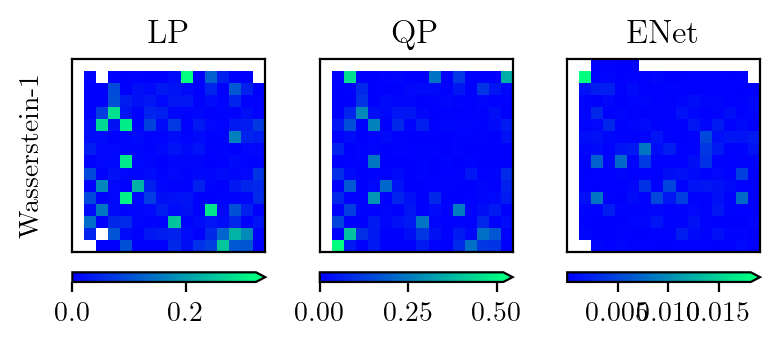

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(4, 3))

cmap_w='winter'

# LP
im1 = axes[0].imshow(w1_map_lp, cmap=cmap_w)
axes[0].set_title("LP")
style_ax(axes[0])
fig.colorbar(im1, ax=axes[0],
             orientation='horizontal',
             location='bottom',
             fraction=0.046, pad=0.04,
             extend='max')
# QP
im3 = axes[1].imshow(w1_map_qp, cmap=cmap_w)
style_ax(axes[1])
axes[1].set_title("QP")
fig.colorbar(im3, ax=axes[1],
             orientation='horizontal',
             location='bottom',
             fraction=0.046, pad=0.04,
             extend='max')
# ENet
im5 = axes[2].imshow(w1_map_enet, cmap=cmap_w)
style_ax(axes[2])
axes[2].set_title("ENet")
fig.colorbar(im5, ax=axes[2],
             orientation='horizontal',
             location='bottom',
             fraction=0.046, pad=0.04,
             extend='max')

# Etiquetas de filas
for row, label in enumerate(["Wasserstein-1"]):
    axes[row].set_ylabel(
        label,
        fontsize=10,
        fontweight='bold',
        rotation=90,
        labelpad=10
    )

plt.tight_layout()
plt.show()

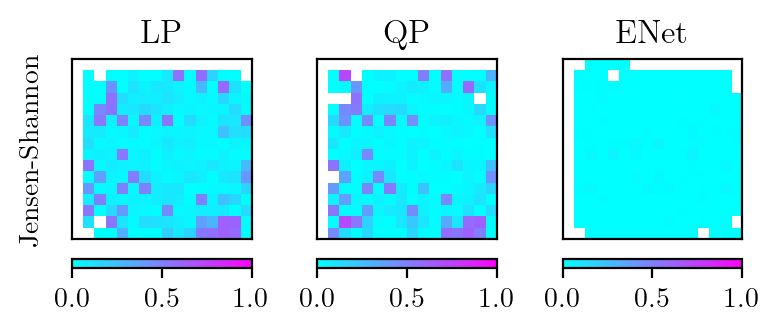

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(4, 3))

cmap_js='cool'

# LP
im1 = axes[0].imshow(js_map_lp, cmap=cmap_js, vmin=0, vmax=1)
axes[0].set_title("LP")
style_ax(axes[0])
fig.colorbar(im1, ax=axes[0],
             orientation='horizontal',
             location='bottom',
             fraction=0.046, pad=0.04)
# QP
im3 = axes[1].imshow(js_map_qp, cmap=cmap_js, vmin=0, vmax=1)
style_ax(axes[1])
axes[1].set_title("QP")
fig.colorbar(im3, ax=axes[1],
             orientation='horizontal',
             location='bottom',
             fraction=0.046, pad=0.04)
# ENet
im5 = axes[2].imshow(js_map_enet, cmap=cmap_js, vmin=0, vmax=1)
style_ax(axes[2])
axes[2].set_title("ENet")
fig.colorbar(im5, ax=axes[2],
             orientation='horizontal',
             location='bottom',
             fraction=0.046, pad=0.04)

# Etiquetas de filas
for row, label in enumerate(["Jensen-Shannon"]):
    axes[row].set_ylabel(
        label,
        fontsize=10,
        fontweight='bold',
        rotation=90,
        labelpad=10
    )

plt.tight_layout()
plt.show()